In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

os.makedirs("artifacts/figures", exist_ok=True)

def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# Загружаем CIFAR10
train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset_name = "CIFAR10"

# Разбиваем на train и val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=generator)

# Загружаем test часть
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for x, y in train_loader:
    print(f"Размер батча X (train): {x.shape}")
    print(f"Размер батча Y (train): {y.shape}")
    print(f"Диапазон значений X: min={x.min().item():.3f}, max={x.max().item():.3f}")
    break

c:\Users\NIU\Documents\Test\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Размер батча X (train): torch.Size([64, 3, 32, 32])
Размер батча Y (train): torch.Size([64])
Диапазон значений X: min=-1.000, max=1.000


In [3]:
class MLP(nn.Module):
    # input_dim 3072 для CIFAR-10 (3*32*32)
    def __init__(self, input_dim: int = 3 * 32 * 32, hidden_dims: tuple = (256, 128), num_classes: int = 10,
                 dropout_p: float = 0.0, use_batchnorm: bool = False):
        super().__init__()
        
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=15, early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train loss={tr_loss:.4f}, acc={tr_acc:.4f} | val loss={va_loss:.4f}, acc={va_acc:.4f}")

        if early_stopping is not None:
            if early_stopping.step(va_acc, model):
                if verbose:
                    print(f"EarlyStopping: остановка на эпохе {epoch}. Лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break
    return history

In [5]:
experiments_results = []

def run_experiment(exp_id, dropout_p=0.0, use_batchnorm=False, early_stopping=None,
                   optimizer_kind="adam", lr=1e-3, weight_decay=0.0, momentum=0.0, epochs=15):
    
    print(f"\n--- Запуск {exp_id} ---")
    set_seed(42)
    
    model = MLP(dropout_p=dropout_p, use_batchnorm=use_batchnorm).to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_kind.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
        
    history = fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=epochs, early_stopping=early_stopping)
    
    best_val_acc = early_stopping.best_score if early_stopping else max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    
    experiments_results.append({
        "experiment_id": exp_id,
        "dataset": dataset_name,
        "seed": 42,
        "model_summary": f"hid=(256,128) | act=relu | dp={dropout_p} | bn={use_batchnorm}",
        "optimizer": optimizer_kind,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_acc"]),
        "best_val_accuracy": round(best_val_acc, 4),
        "best_val_loss": round(best_val_loss, 4)
    })
    
    return model, history

In [6]:
# E1 (base)
model_e1, hist_e1 = run_experiment("E1", dropout_p=0.0, use_batchnorm=False)

# E2 (Dropout)
model_e2, hist_e2 = run_experiment("E2", dropout_p=0.3, use_batchnorm=False)

# E3 (BatchNorm)
model_e3, hist_e3 = run_experiment("E3", dropout_p=0.0, use_batchnorm=True)

# Ищем лучший между E2 и E3
e2_best_acc = max(hist_e2["val_acc"])
e3_best_acc = max(hist_e3["val_acc"])

best_dropout = 0.3 if e2_best_acc > e3_best_acc else 0.0
best_bn = False if e2_best_acc > e3_best_acc else True

print(f"\nЛучший между E2 и E3: {'E2 (Dropout)' if e2_best_acc > e3_best_acc else 'E3 (BatchNorm)'}")

# E4 (EarlyStopping)
es = EarlyStopping(patience=3, min_delta=0.0)
model_e4, hist_e4 = run_experiment("E4", dropout_p=best_dropout, use_batchnorm=best_bn, early_stopping=es, epochs=25)

# Сохранение лучшей модели (E4) и конфига
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")

best_config = {
    "dataset": dataset_name,
    "seed": 42,
    "input_dim": 3 * 32 * 32,
    "hidden_dims": [256, 128],
    "num_classes": 10,
    "activation": "relu",
    "dropout_p": best_dropout,
    "use_batchnorm": best_bn,
    "optimizer": "Adam",
    "lr": 1e-3,
    "early_stopping_patience": 3
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

# Проверка на test
test_loss, test_acc = evaluate(model_e4, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nFinal Test Evaluation (E4): loss={test_loss:.4f}, acc={test_acc:.4f}")


--- Запуск E1 ---
Epoch 01/15 | train loss=1.6617, acc=0.4103 | val loss=1.5502, acc=0.4570
Epoch 02/15 | train loss=1.4585, acc=0.4855 | val loss=1.4652, acc=0.4844
Epoch 03/15 | train loss=1.3463, acc=0.5249 | val loss=1.4057, acc=0.5141
Epoch 04/15 | train loss=1.2627, acc=0.5501 | val loss=1.4704, acc=0.4915
Epoch 05/15 | train loss=1.1871, acc=0.5773 | val loss=1.3894, acc=0.5202
Epoch 06/15 | train loss=1.1127, acc=0.6056 | val loss=1.4179, acc=0.5172
Epoch 07/15 | train loss=1.0515, acc=0.6252 | val loss=1.4270, acc=0.5226
Epoch 08/15 | train loss=0.9827, acc=0.6493 | val loss=1.4633, acc=0.5187
Epoch 09/15 | train loss=0.9219, acc=0.6717 | val loss=1.5091, acc=0.5217
Epoch 10/15 | train loss=0.8655, acc=0.6946 | val loss=1.5189, acc=0.5237
Epoch 11/15 | train loss=0.8096, acc=0.7112 | val loss=1.5969, acc=0.5167
Epoch 12/15 | train loss=0.7528, acc=0.7304 | val loss=1.6645, acc=0.5168
Epoch 13/15 | train loss=0.7050, acc=0.7511 | val loss=1.7124, acc=0.5203
Epoch 14/15 | train

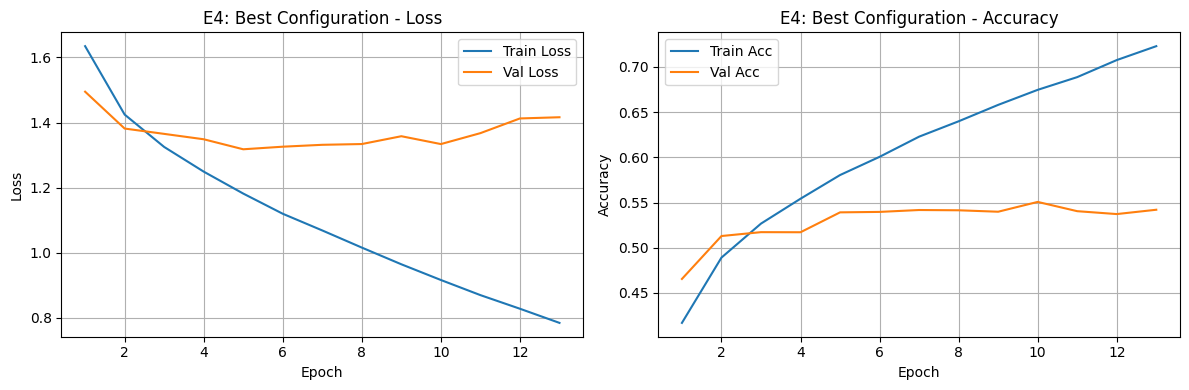

In [7]:
def plot_and_save_curves(history, save_path, title):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"], label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} - Loss")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(epochs, history["train_acc"], label="Train Acc")
    ax2.plot(epochs, history["val_acc"], label="Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} - Accuracy")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_and_save_curves(hist_e4, "artifacts/figures/curves_best.png", "E4: Best Configuration")

In [8]:
# Фиксированная архитектура (из E4)
# O1 (LR слишком большой)
_, hist_o1 = run_experiment("O1", dropout_p=best_dropout, use_batchnorm=best_bn, 
                            optimizer_kind="adam", lr=1e-1, epochs=8)

# O2 (LR слишком маленький)
_, hist_o2 = run_experiment("O2", dropout_p=best_dropout, use_batchnorm=best_bn, 
                            optimizer_kind="adam", lr=1e-5, epochs=8)

# O3 (SGD+momentum + weight decay)
_, hist_o3 = run_experiment("O3", dropout_p=best_dropout, use_batchnorm=best_bn, 
                            optimizer_kind="sgd", lr=1e-2, momentum=0.9, weight_decay=1e-4, epochs=15)


--- Запуск O1 ---
Epoch 01/8 | train loss=1.8586, acc=0.3284 | val loss=1.7363, acc=0.3809
Epoch 02/8 | train loss=1.6945, acc=0.3871 | val loss=1.6244, acc=0.4166
Epoch 03/8 | train loss=1.6148, acc=0.4221 | val loss=1.5864, acc=0.4490
Epoch 04/8 | train loss=1.5639, acc=0.4421 | val loss=1.5384, acc=0.4575
Epoch 05/8 | train loss=1.5158, acc=0.4607 | val loss=1.5437, acc=0.4501
Epoch 06/8 | train loss=1.4894, acc=0.4753 | val loss=1.4972, acc=0.4713
Epoch 07/8 | train loss=1.4447, acc=0.4857 | val loss=1.5016, acc=0.4752
Epoch 08/8 | train loss=1.4274, acc=0.4933 | val loss=1.5351, acc=0.4588

--- Запуск O2 ---
Epoch 01/8 | train loss=1.9892, acc=0.3114 | val loss=1.8412, acc=0.3850
Epoch 02/8 | train loss=1.7869, acc=0.4052 | val loss=1.7371, acc=0.4187
Epoch 03/8 | train loss=1.7025, acc=0.4345 | val loss=1.6736, acc=0.4397
Epoch 04/8 | train loss=1.6439, acc=0.4509 | val loss=1.6312, acc=0.4540
Epoch 05/8 | train loss=1.5941, acc=0.4687 | val loss=1.5984, acc=0.4646
Epoch 06/8 | 

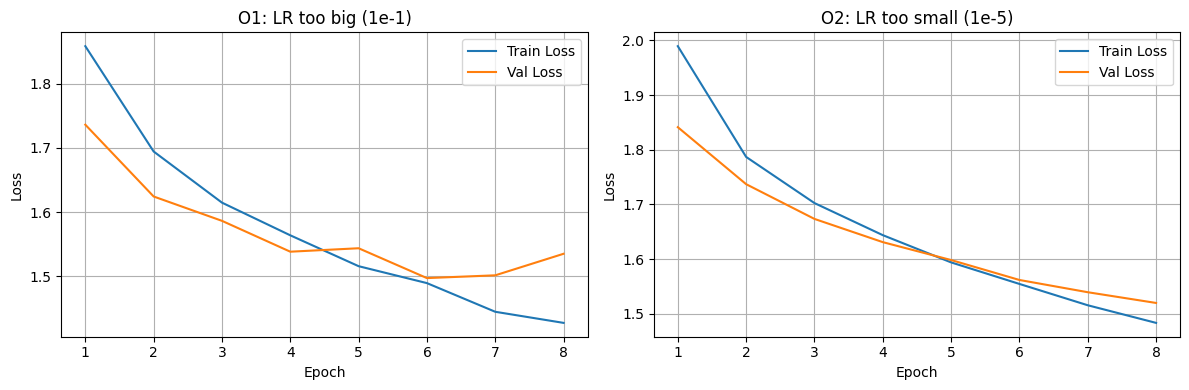

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.0 | bn=False",adam,0.00100,0.0,0.0000,15,0.5237,1.3894
1,E2,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.3 | bn=False",adam,0.00100,0.0,0.0000,15,0.5261,1.3549
2,E3,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.0 | bn=True",adam,0.00100,0.0,0.0000,15,0.5507,1.3180
3,E4,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.0 | bn=True",adam,0.00100,0.0,0.0000,13,0.5507,1.3180
4,O1,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.0 | bn=True",adam,0.10000,0.0,0.0000,8,0.4752,1.4972
5,O2,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.0 | bn=True",adam,0.00001,0.0,0.0000,8,0.4859,1.5200
6,O3,CIFAR10,42,"hid=(256,128) | act=relu | dp=0.0 | bn=True",sgd,0.01000,0.9,0.0001,15,0.5477,1.3251


In [9]:
# Графики экстремальных LR (O1 и O2)
epochs_o1 = np.arange(1, len(hist_o1["train_loss"]) + 1)
epochs_o2 = np.arange(1, len(hist_o2["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_o1, hist_o1["train_loss"], label="Train Loss")
ax1.plot(epochs_o1, hist_o1["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("O1: LR too big (1e-1)")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_o2, hist_o2["train_loss"], label="Train Loss")
ax2.plot(epochs_o2, hist_o2["val_loss"], label="Val Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("O2: LR too small (1e-5)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()

df_runs = pd.DataFrame(experiments_results)
df_runs.to_csv("artifacts/runs.csv", index=False)
display(df_runs)